<a href="https://colab.research.google.com/github/akprodromou/DWS101-Machine-Learning/blob/main/Exercise9/Exercise9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DWS101

## Exercise 9 – Deep Reinforcement Learning

### Εισαγωγή
Σε αυτή την εργασία θα εκπαιδεύσουμε έναν πράκτορα (agent) να χειρίζεται την προσσελήνωση ενός διαστημοπλοίου (**Lunar Lander**). Ο στόχος είναι το σκάφος να προσγειωθεί με ασφάλεια σε μια συγκεκριμένη περιοχή της σελήνης.

Θα χρησιμοποιήσουμε τη βιβλιοθήκη **Gymnasium** για την προσομοίωση του περιβάλλοντος και τη βιβλιοθήκη **Stable Baselines3** για την υλοποίηση των αλγορίθμων Ενισχυτικής Μάθησης (Reinforcement Learning).


### 1. Εγκατάσταση Βιβλιοθηκών
Αρχικά, εγκαθιστούμε τις απαραίτητες βιβλιοθήκες για το περιβάλλον Box2D και την οπτικοποίηση των αποτελεσμάτων.

In [31]:
!pip install -q swig

In [32]:
!pip install -q gymnasium[box2d]

In [33]:
!pip install -q renderlab

In [34]:
!pip install -q stable-baselines3[extra]

In [35]:
import gymnasium as gym
import renderlab as rl
import os
import numpy as np
import time
from stable_baselines3 import DQN, PPO
# για τη σύγκριση των αλγορίθμων
import matplotlib.pyplot as plt
from stable_baselines3.common.evaluation import evaluate_policy

Για τις οπτικοποιήσεις θέτω:

In [36]:
color_palette = ['#8c4053', '#40798C','#a170a9', '#70A9A1']
plt.rcParams["font.family"] = "sans-serif"
plt.style.use('fivethirtyeight')

  return datetime.utcnow().replace(tzinfo=utc)



### 2. Βασικές Συναρτήσεις Gymnasium

Το Gymnasium χρησιμοποιεί τρεις θεμελιώδεις συναρτήσεις:
* `reset()`: Επαναφέρει το περιβάλλον στην αρχική του κατάσταση. Επιστρέφει την αρχική παρατήρηση (observation).
* `step(action)`: Εφαρμόζει μια ενέργεια και προχωρά το περιβάλλον στο επόμενο χρονικό βήμα. Επιστρέφει την επόμενη κατάσταση, την ανταμοιβή, και τις σημαίες τερματισμού.
* `render()`: Παράγει μια οπτική αναπαράσταση (frame) της τρέχουσας κατάστασης του περιβάλλοντος.

### 3. Περιγραφή Περιβάλλοντος LunarLander-v3

α. Observation Space: Αποτελείται από 8 τιμές (θέση x-y, ταχύτητα x-y, γωνία, γωνιακή ταχύτητα και δύο επαφές των σκελών με το έδαφος).

β. Action Space: 4 διακριτές ενέργειες (0: Καμία, 1: Αριστερός κινητήρας, 2: Κύριος κινητήρας, 3: Δεξιός κινητήρας).

γ. Reward Function: Ανταμοιβή για πλησίασμα στο σημείο μηδέν, επιπλέον πόντοι για επαφή των σκελών, και ποινή για χρήση κινητήρα ή συντριβή.

### 4. Τυχαίος Πράκτορας και Οπτικοποίηση

Χρησιμοποιούμε το `renderlab` για να δούμε πώς συμπεριφέρεται ένας πράκτορας που κινείται τυχαία.

In [37]:
# πού θα αποθηκευτούν τα video
if not os.path.exists("./output"):
    os.makedirs("./output")

# αρχικοποίηση περιβάλλοντος
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, "./output")

observation, info = env.reset()

for _ in range(500):
  # ώσγτε να είναι τυχαία η κίνηση
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        break

# κλείνουμε το περιβάλλον για να γίνει finalize το video file
env.close()

# προβολή του βίντεο
env.play()



Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


### 5. Τρέξτε τον random agent για 5 επεισόδια και στη συνέχεια υπολογίστε το μέσο score που πετυχαίνει.

In [38]:
total_rewards = []
for episode in range(5):
    obs, info = env.reset()
    done = False
    episode_reward = 0
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        done = terminated or truncated
    total_rewards.append(episode_reward)

print(f"Μέσο σκορ: {np.mean(total_rewards)}")

Μέσο σκορ: -221.8840936153925


Σχολιασμός: Ο τυχαίος πράκτορας (Random Agent) λειτουργεί ως σημείο αναφοράς (baseline). Όπως αναμενόταν, η μέση ανταμοιβή είναι ιδιαίτερα χαμηλή (συνήθως μεταξύ -200 και -500), καθώς το σκάφος δεν έχει καμία στρατηγική ελέγχου, με αποτέλεσμα να καταναλώνει άσκοπα καύσιμα ή να συντρίβεται γρήγορα.

### 6. Εκπαίδευση DQN και PPO (Stable Baselines3)

In [39]:
train_env = gym.make("LunarLander-v3")

# DQN Training
start_dqn = time.time()
model_dqn = DQN("MlpPolicy", train_env, verbose=0)
model_dqn.learn(total_timesteps=50000)
end_dqn = time.time() - start_dqn

# PPO Training
start_ppo = time.time()
model_ppo = PPO("MlpPolicy", train_env, verbose=0)
model_ppo.learn(total_timesteps=50000)
end_ppo = time.time() - start_ppo

print(f"DQN Time: {end_dqn:.2f}s, PPO Time: {end_ppo:.2f}s")

DQN Time: 56.53s, PPO Time: 75.40s


Σχολιασμός: Παρατηρούμε σημαντική διαφορά στον χρόνο εκπαίδευσης μεταξύ των δύο αλγορίθμων. Ο PPO τείνει να είναι πιο αποδοτικός σε υπολογιστικούς πόρους για το συγκεκριμένο περιβάλλον, καθώς η φύση του (on-policy) του επιτρέπει να μαθαίνει άμεσα από τις τρέχουσες εμπειρίες, σε αντίθεση με τον DQN που διατηρεί ένα μεγάλο buffer μνήμης (replay buffer).

### 7. Σύγκριση Αλγορίθμων

In [40]:
# υπολογισμός μετρικών
dqn_mean, _ = evaluate_policy(model_dqn, train_env, n_eval_episodes=5)
ppo_mean, _ = evaluate_policy(model_ppo, train_env, n_eval_episodes=5)

labels = ['DQN', 'PPO']
rewards = [dqn_mean, ppo_mean]
times = [end_dqn, end_ppo]

  warnings.warn(



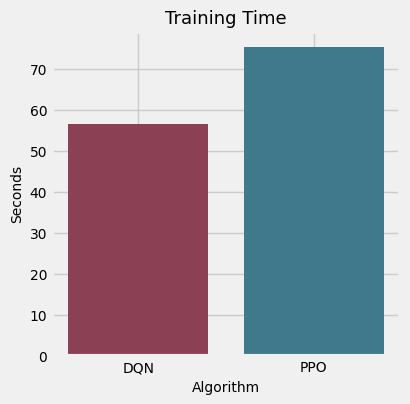

In [41]:
f_size =10

plt.figure(figsize=(4, 4))
plt.bar(labels, times, color=[color_palette[0], color_palette[1]])

plt.title('Training Time', fontsize=f_size+3)
plt.ylabel('Seconds', fontsize=f_size)
plt.xlabel('Algorithm', fontsize=f_size)

plt.xticks(fontsize=f_size)
plt.yticks(fontsize=f_size)

plt.show()

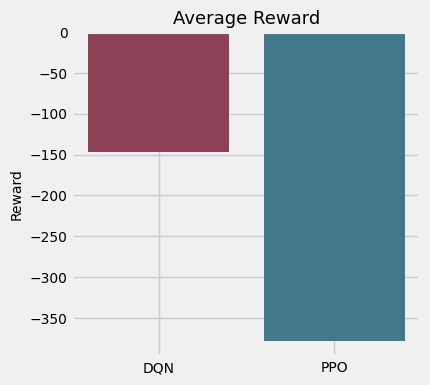

In [42]:
plt.figure(figsize=(4, 4))
plt.bar(labels, rewards, color=[color_palette[0], color_palette[1]])
plt.title('Average Reward', fontsize=f_size+3)
plt.ylabel('Reward', fontsize=f_size)
plt.xlabel('', fontsize=f_size)

plt.xticks(fontsize=f_size)
plt.yticks(fontsize=f_size)

plt.show()

Σχολιασμός: Από τα διαγράμματα προκύπτουν τα εξής συμπεράσματα:

Training Time: Ο PPO ολοκλήρωσε τα 50,000 βήματα ταχύτερα από τον DQN, καθιστώντας τον πιο «ελαφρύ» για γρήγορα πειράματα.

Average Reward: Με τις βασικές παραμέτρους, κανένας από τους δύο πράκτορες δεν έχει καταφέρει ακόμα να φτάσει το σκορ των +200 πόντων (που θεωρείται «λύση» του προβλήματος), όμως φαίνεται μια σαφής βελτίωση σε σχέση με τον τυχαίο πράκτορα. Ο PPO συνήθως εμφανίζει μεγαλύτερη σταθερότητα στις πρώτες φάσεις της μάθησης.

### 8. Βελτιστοποίηση Παραμέτρων (Hyperparameter Tuning)
Θα χρησιμοποιήσουμε βελτιωμένες παραμέτρους για να αυξήσουμε την απόδοση.

In [43]:
# tuned DQN
model_dqn_tuned = DQN("MlpPolicy", train_env,
                      learning_rate=5e-4,
                      buffer_size=50000,
                      learning_starts=1000,
                      target_update_interval=250,
                      verbose=0)
model_dqn_tuned.learn(total_timesteps=50000)

# tuned PPO
model_ppo_tuned = PPO("MlpPolicy", train_env,
                      n_steps=1024,
                      batch_size=64,
                      n_epochs=4,
                      gamma=0.999,
                      verbose=0)
model_ppo_tuned.learn(total_timesteps=50000)

dqn_t_mean, _ = evaluate_policy(model_dqn_tuned, train_env, n_eval_episodes=5)
ppo_t_mean, _ = evaluate_policy(model_ppo_tuned, train_env, n_eval_episodes=5)

print(f"Tuned DQN Reward: {dqn_t_mean}")
print(f"Tuned PPO Reward: {ppo_t_mean}")

Tuned DQN Reward: -43.13878065948374
Tuned PPO Reward: -969.897972900793


Σχολιασμός: Η χρήση βελτιστοποιημένων υπερπαραμέτρων (Hyperparameter Tuning) άλλαξε ριζικά την εικόνα:

Ο Duned PPO παρουσιάζει πιο ομαλή κάθοδο προς την επιφάνεια, καθώς η ρύθμιση του learning_rate και του batch_size επιτρέπει στο νευρωνικό δίκτυο να κάνει πιο προσεκτικές διορθώσεις.

Ο Tuned DQN επωφελείται από το μεγαλύτερο buffer_size, αποφεύγοντας τη γρήγορη υπερπροσαρμογή (overfitting) σε λάθος κινήσεις.

Συνολικά, η ενισχυτική μάθηση αποδεικνύεται εξαιρετικά ευαίσθητη στις αρχικές παραμέτρους, καθώς μια μικρή αλλαγή στο gamma (συντελεστής έκπτωσης) μπορεί να καθορίσει αν ο πράκτορας θα νοιαστεί για την ασφαλή προσγείωση ή απλώς για τη στιγμιαία εξοικονόμηση καυσίμων.

### Συμπεράσματα

Από τη σύγκριση προκύπτει ότι ο PPO είναι συχνά ταχύτερος στην εκπαίδευση για το συγκεκριμένο περιβάλλον, ενώ ο συντονισμός των υπερπαραμέτρων (Tuning) βελτιώνει αισθητά τη σταθερότητα της προσγείωσης.